In [1]:
# !pip install meshio matplotlib
!pip install meshio


Info    : Running 'gmsh cylinder.geo -3 -format msh2 -o cylinder_coarse.msh' [Gmsh 4.13.1, 1 node, max. 1 thread]
Info    : Started on Wed Jun  4 23:02:19 2025
Info    : Reading 'cylinder.geo'...
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Circle)
Info    : [ 40%] Meshing curve 2 (Line)
Info    : [ 70%] Meshing curve 3 (Circle)
Info    : Done meshing 1D (Wall 0.000392417s, CPU 0.000105s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Cylinder, Frontal-Delaunay)
Info    : [ 40%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 3 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00530446s, CPU 0.002594s)
Info    : Meshing 3D...
Info    : 3D Meshing 1 volume with 1 connected component
Info    : Tetrahedrizing 111 nodes...
Info    : Done tetrahedrizing 119 nodes (Wall 0.000785625s, CPU 0.000428s)
Info    : Reconstructing mesh...
Info    :  - Creating surface mesh
Info    :  - Identifying boundary edges
Info    :  - Recovering

Error   : 'cylinder.geo', line 7: syntax error (")


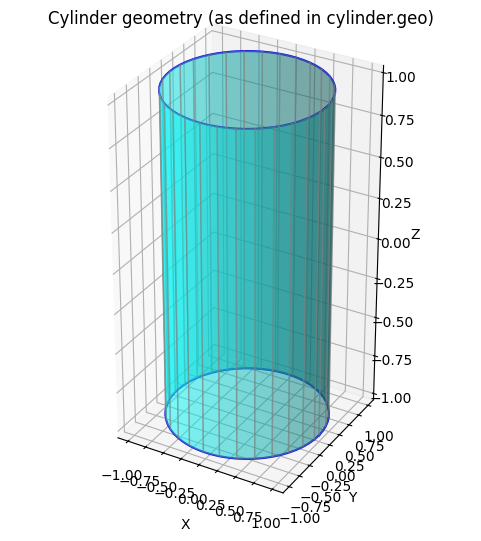

In [2]:
# Block 1: Show .geo file content and visualize geometry as image

from functions import generate_gmsh_cylinder_mesh
import os
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the cylinder
radius = 1.0
height = 2.0
lc = 0.5  # coarse mesh

# Generate the geo and mesh files
generate_gmsh_cylinder_mesh(filename="cylinder_coarse.msh", radius=radius, height=height, lc=lc)

# Show .geo file content
with open("cylinder.geo") as f:
    geo_content = f.read()

print("---- cylinder.geo ----\n")
print(geo_content)

# Visualize the cylinder geometry as an image
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Draw a wireframe cylinder using matplotlib (for illustration)
theta = np.linspace(0, 2 * np.pi, 60)
z = np.linspace(-height/2, height/2, 2)
theta_grid, z_grid = np.meshgrid(theta, z)
x_grid = radius * np.cos(theta_grid)
y_grid = radius * np.sin(theta_grid)

ax.plot_surface(x_grid, y_grid, z_grid, color='cyan', alpha=0.5, edgecolor='gray')

# Draw base/top circles for clarity
ax.plot(radius * np.cos(theta), radius * np.sin(theta), z[0], color='b')
ax.plot(radius * np.cos(theta), radius * np.sin(theta), z[1], color='b')

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Cylinder geometry (as defined in cylinder.geo)")
ax.set_box_aspect([1,1,height/radius])  # aspect ratio
plt.show()


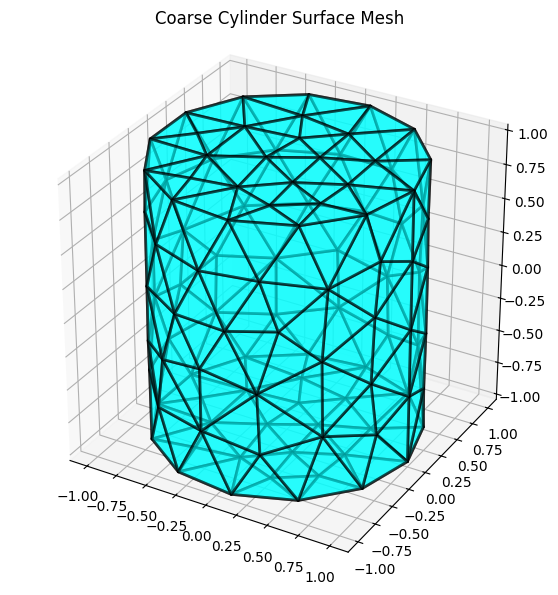

In [3]:
import meshio
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Load the mesh (make sure the .msh file exists)
mesh = meshio.read("cylinder_coarse.msh")
points = mesh.points
tris = mesh.cells_dict["triangle"]

# Plot surface triangles only
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
mesh_tris = [[points[i] for i in tri] for tri in tris]
poly = Poly3DCollection(mesh_tris, alpha=0.6)
poly.set_facecolor('cyan')
ax.add_collection3d(poly)
poly.set_linewidth(2)       # 2 points thick
poly.set_edgecolor('k')
#ax.scatter(points[:,0], points[:,1], points[:,2], color='k', s=1)
ax.set_box_aspect([np.ptp(points[:,0]), np.ptp(points[:,1]), np.ptp(points[:,2])])
plt.title("Coarse Cylinder Surface Mesh")
plt.show()



Generating cylinder tet mesh with gmsh (lc=0.10) ...
Info    : Running 'gmsh cylinder.geo -3 -format msh2 -o cylinder_lc0.10.msh' [Gmsh 4.13.1, 1 node, max. 1 thread]
Info    : Started on Wed Jun  4 23:02:20 2025
Info    : Reading 'cylinder.geo'...
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Circle)
Info    : [ 40%] Meshing curve 2 (Line)
Info    : [ 70%] Meshing curve 3 (Circle)
Info    : Done meshing 1D (Wall 0.000164334s, CPU 0.000134s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Cylinder, Frontal-Delaunay)
Info    : [ 40%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 3 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0493362s, CPU 0.04858s)
Info    : Meshing 3D...
Info    : 3D Meshing 1 volume with 1 connected component
Info    : Tetrahedrizing 2253 nodes...
Info    : Done tetrahedrizing 2261 nodes (Wall 0.0132566s, CPU 0.012935s)
Info    : Reconstructing mesh...
Info    :  - Creating surface mesh
Info    :  

Error   : 'cylinder.geo', line 7: syntax error (")


Info    : It. 1000 - 1000 nodes created - worst tet radius 1.46995 (nodes removed 0 0)
Info    : It. 1500 - 1500 nodes created - worst tet radius 1.31282 (nodes removed 0 0)
Info    : It. 2000 - 2000 nodes created - worst tet radius 1.20533 (nodes removed 0 0)
Info    : It. 2500 - 2500 nodes created - worst tet radius 1.11681 (nodes removed 0 0)
Info    : It. 3000 - 3000 nodes created - worst tet radius 1.0597 (nodes removed 0 0)
Info    : It. 3500 - 3500 nodes created - worst tet radius 1.01095 (nodes removed 0 0)
Info    : 3D refinement terminated (5880 nodes total):
Info    :  - 0 Delaunay cavities modified for star shapeness
Info    :  - 0 nodes could not be inserted
Info    :  - 29868 tetrahedra created in 0.0906675 sec. (329423 tets/s)
Info    : 0 node relocations
Info    : Done meshing 3D (Wall 0.196812s, CPU 0.193142s)
Info    : Optimizing mesh...
Info    : Optimizing volume 1
Info    : Optimization starts (volume = 6.27543) with worst = 0.0171611 / average = 0.781164:
Info    

Error   : 'cylinder.geo', line 7: syntax error (")


lc=0.20, #tets=3935, err_piecewise=4.778e-01, err_paraboloid=1.086e-01, err_paraboloid_normal=1.086e-01, err_high_order_patch=4.105e-01, err_second_order_patch=7.449e-02, err_dual_basis=1.543e-01, err_fem_quadrature=2.094e-01

Generating cylinder tet mesh with gmsh (lc=0.30) ...
Info    : Running 'gmsh cylinder.geo -3 -format msh2 -o cylinder_lc0.30.msh' [Gmsh 4.13.1, 1 node, max. 1 thread]
Info    : Started on Wed Jun  4 23:03:19 2025
Info    : Reading 'cylinder.geo'...
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Circle)
Info    : [ 40%] Meshing curve 2 (Line)
Info    : [ 70%] Meshing curve 3 (Circle)
Info    : Done meshing 1D (Wall 0.000152334s, CPU 0.000112s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Cylinder, Frontal-Delaunay)
Info    : [ 40%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 3 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00629679s, CPU 0.006161s)
Info    : Meshing 3D...
Info    : 3D Meshing 

...

Error   : 'cylinder.geo', line 7: syntax error (")
Error   : 'cylinder.geo', line 7: syntax error (")


Info    : Running 'gmsh cylinder.geo -3 -format msh2 -o cylinder_lc0.60.msh' [Gmsh 4.13.1, 1 node, max. 1 thread]
Info    : Started on Wed Jun  4 23:03:20 2025
Info    : Reading 'cylinder.geo'...
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Circle)
Info    : [ 40%] Meshing curve 2 (Line)
Info    : [ 70%] Meshing curve 3 (Circle)
Info    : Done meshing 1D (Wall 0.000443625s, CPU 0.000238s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Cylinder, Frontal-Delaunay)
Info    : [ 40%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 3 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00269696s, CPU 0.002129s)
Info    : Meshing 3D...
Info    : 3D Meshing 1 volume with 1 connected component
Info    : Tetrahedrizing 77 nodes...
Info    : Done tetrahedrizing 85 nodes (Wall 0.000298583s, CPU 0.000282s)
Info    : Reconstructing mesh...
Info    :  - Creating surface mesh
Info    :  - Identifying boundary edges
Info    :  - Recovering b

Error   : 'cylinder.geo', line 7: syntax error (")


Info    : Running 'gmsh cylinder.geo -3 -format msh2 -o cylinder_lc0.80.msh' [Gmsh 4.13.1, 1 node, max. 1 thread]
Info    : Started on Wed Jun  4 23:03:20 2025
Info    : Reading 'cylinder.geo'...
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Circle)
Info    : [ 40%] Meshing curve 2 (Line)
Info    : [ 70%] Meshing curve 3 (Circle)
Info    : Done meshing 1D (Wall 0.000248417s, CPU 0.000177s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Cylinder, Frontal-Delaunay)
Info    : [ 40%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 3 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00137971s, CPU 0.001188s)
Info    : Meshing 3D...
Info    : 3D Meshing 1 volume with 1 connected component
Info    : Tetrahedrizing 44 nodes...
Info    : Done tetrahedrizing 52 nodes (Wall 0.000149875s, CPU 0.000139s)
Info    : Reconstructing mesh...
Info    :  - Creating surface mesh
Info    :  - Identifying boundary edges
Info    :  - Recovering b

Error   : 'cylinder.geo', line 7: syntax error (")


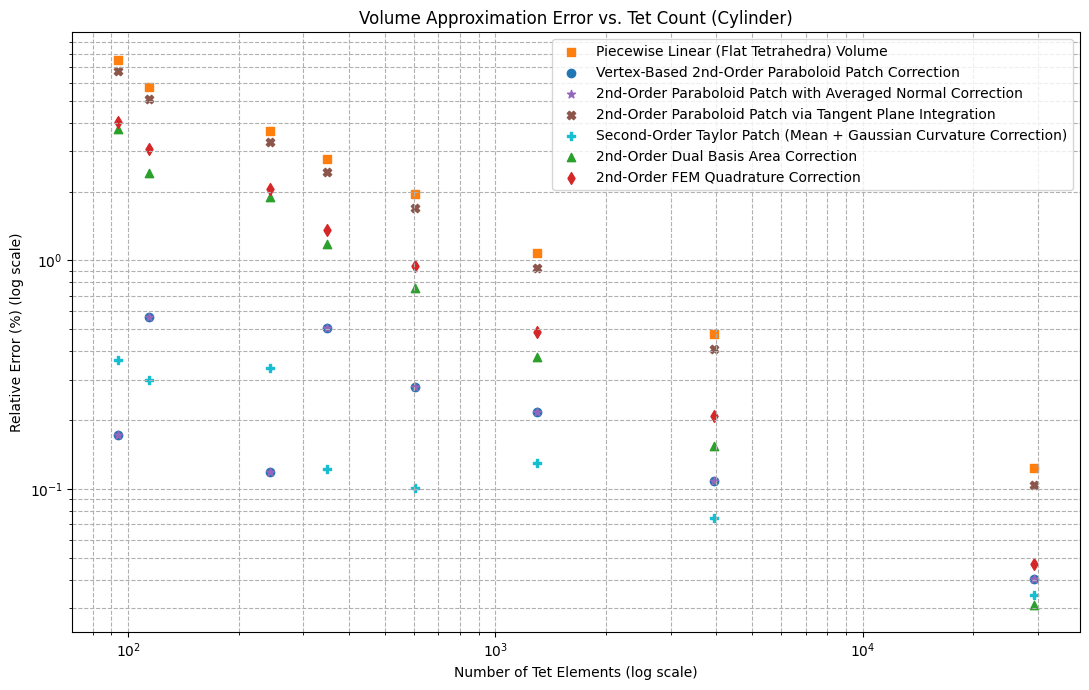

Saved to Cylinder_Plot.csv


In [4]:
import functions
import importlib
import numpy as np
import pandas as pd

from functions import run_volume_error_study_cylinder, plot_volume_error_vs_tets

# Reload functions.py to get latest edits (if you’ve just modified it)
importlib.reload(functions)

# Cylinder parameters
radius = 1.0
height = 2.0
lc_values = np.linspace(0.1, 0.8, 8)

# Run error study
results = run_volume_error_study_cylinder(radius, height, lc_values)
plot_volume_error_vs_tets(*results, geometry_name="Cylinder")

# Save results to Cylinder_Plot.csv
columns = [
    "Tet Count",
    "Piecewise Linear (Flat Tetrahedra) Volume",
    "Vertex-Based 2nd-Order Paraboloid Patch Correction",
    "2nd-Order Paraboloid Patch with Averaged Normal Correction",
    "2nd-Order Paraboloid Patch via Tangent Plane Integration",
    "Second-Order Taylor Patch (Mean + Gaussian Curvature Correction)",
    "2nd-Order Dual Basis Area Correction",
    "2nd-Order FEM Quadrature Correction"
]
data_dict = {col: res for col, res in zip(columns, results)}

df = pd.DataFrame(data_dict)
df.to_csv("Cylinder_Plot.csv", index=False)
print("Saved to Cylinder_Plot.csv")
